# Simple conditional edge (one router, N destinations)

The most common pattern. After a node runs, a router function inspects the state and returns a string key telling LangGraph which node to go to next.

In [52]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [53]:
load_dotenv()

True

In [54]:
model = ChatOpenAI(model="gpt-4o-mini")

In [55]:
STORE_PROMPT = """You are a helpful customer support assistant for "Fresh Basket" — a local grocery store.

Store details:
- Name: Fresh Basket
- Location: 12 Main Street, Lahore
- Working hours: Mon-Sat 8:00 AM - 10:00 PM, Sunday 10:00 AM - 8:00 PM
- Contact: +92-300-1234567 | freshbasket@email.com

What we sell:
- Fresh fruits & vegetables (daily delivery from local farms)
- Dairy products: milk, yogurt, cheese, butter, eggs
- Bakery: fresh bread, croissants, cakes (baked every morning)
- Meat & poultry: chicken, beef, mutton (halal certified)
- Pantry staples: rice, flour, lentils, cooking oil, spices
- Beverages: juices, soft drinks, water, tea, coffee
- Frozen foods, snacks, and household cleaning supplies

Policies:
- Free home delivery on orders above Rs. 2,000
- Returns accepted within 24 hours with receipt
- We do NOT sell alcohol or non-halal products

Always be warm, helpful, and respond in the same language the customer uses.
"""

In [56]:
class CustomerCareState(TypedDict):
    user_message: str
    intent: str
    response: str

In [57]:
def classify_intent(state: CustomerCareState) -> CustomerCareState:
    user_message = state["user_message"]
    prompt = f"""Classify this message into exactly one word: question, complaint, or feedback.
        Message: {user_message}
        Reply with only the single word.
    """
    response = model.invoke(prompt)
    return {"intent": response.content.strip().lower() } 
    

In [58]:
def handle_question(state: CustomerCareState) -> CustomerCareState:
    result = model.invoke([
        SystemMessage(content=STORE_PROMPT + "\nThe customer has a question. Answer it accurately using the store information above."),
        HumanMessage(content=state["user_message"]),
    ])
    return {"response": result.content }

In [59]:
def handle_complaint(state: CustomerCareState) -> CustomerCareState:
    result = model.invoke([
        SystemMessage(content=STORE_PROMPT + "\nThe customer has a complaint. Respond with empathy, apologise sincerely, and offer a concrete resolution based on store policies."),
        HumanMessage(content=state["user_message"]),
    ])
    return {"response": result.content }

In [60]:
def handle_feedback(state: CustomerCareState) -> CustomerCareState:
    result = model.invoke([
        SystemMessage(content=STORE_PROMPT + "\nThe customer has left feedback. Acknowledge it warmly, thank them, and mention any relevant store details if appropriate."),
        HumanMessage(content=state["user_message"]),
    ])
    return {"response": result.content }

In [61]:
def router(state: CustomerCareState) -> str:
    intent = state["intent"]
    if intent == "question":
        return "handle_question"
    elif intent == "complaint":
        return "handle_complaint"
    elif intent == "feedback":
        return "handle_feedback"
    else:
        raise ValueError(f"Unknown intent: {intent}")

In [62]:
graph = StateGraph(CustomerCareState)

graph.add_node("classify_intent", classify_intent)
graph.add_node("handle_question", handle_question)
graph.add_node("handle_complaint", handle_complaint)
graph.add_node("handle_feedback", handle_feedback)

graph.add_edge(START, "classify_intent")
graph.add_conditional_edges(
    "classify_intent", 
    router,
    {
        "handle_question": "handle_question",
        "handle_complaint": "handle_complaint",
        "handle_feedback": "handle_feedback"
    }
)

graph.add_edge("handle_question",  END)
graph.add_edge("handle_complaint", END)
graph.add_edge("handle_feedback",  END)

workflow = graph.compile()

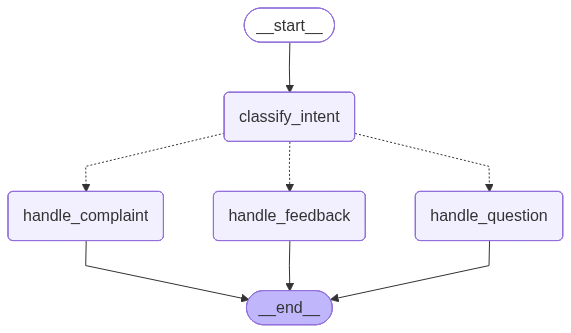

In [63]:
workflow

In [64]:
workflow.invoke({"user_message": "I have a problem with my order."})

{'user_message': 'I have a problem with my order.',
 'intent': 'complaint',
 'response': "I'm really sorry to hear that you're having a problem with your order. Can you please provide me with more details about the issue? I'll do my best to help you resolve it as quickly as possible."}

In [65]:
workflow.invoke({"user_message": "I love the new features in the app!"})

{'user_message': 'I love the new features in the app!',
 'intent': 'feedback',
 'response': "Thank you so much for your wonderful feedback! We're thrilled to hear that you love the new features in our app. We always strive to enhance your shopping experience at Fresh Basket. If you have any suggestions or need assistance with anything, feel free to reach out. Happy shopping!"}

In [66]:
workflow.invoke({"user_message": "What are your store hours?"})

{'user_message': 'What are your store hours?',
 'intent': 'question',
 'response': 'Our store hours are as follows:\n- Monday to Saturday: 8:00 AM - 10:00 PM\n- Sunday: 10:00 AM - 8:00 PM\n\nFeel free to visit us during these hours!'}